# EDA for DPOY Award

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
import os


In [2]:
# Establishing file paths for loading and saving data
CLEANED_PATH = "../../data/cleaned"
PROCESSED_PATH = "../../data/processed"
os.makedirs(PROCESSED_PATH, exist_ok=True)

The first phase of EDA will be to determine which categories matter most for the DPOY award

In [3]:
# Importing the merged data set from notebook 01
players_df = pd.read_csv(f"{CLEANED_PATH}/player_all_years.csv")

In [4]:
# Previewing the data to ensure this is the correct DataFrame
players_df.head(5)

,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,WS,WS/48,OBPM,DBPM,BPM,VORP,is_MVP,is_DPOY,is_PPG_Leader,Season
0,Kevin Durant,21.0,OKC,SF,82.0,82.0,39.5,9.7,20.3,0.476,...,16.1,0.238,6.3,0.8,7.1,7.5,False,False,True,2010
1,LeBron James,25.0,CLE,SF,76.0,76.0,39.0,10.1,20.1,0.503,...,18.5,0.299,9.1,2.8,11.8,10.3,True,False,False,2010
2,Carmelo Anthony,25.0,DEN,SF,69.0,69.0,38.2,10.0,21.8,0.458,...,7.9,0.145,3.5,-1.2,2.3,2.9,False,False,False,2010
3,Kobe Bryant,31.0,LAL,SG,73.0,73.0,38.8,9.8,21.5,0.456,...,9.4,0.160,3.9,0.2,4.1,4.4,False,False,False,2010
4,Dwyane Wade,28.0,MIA,SG,77.0,77.0,36.3,9.3,19.6,0.476,...,13.0,0.224,7.1,2.1,9.2,7.9,False,False,False,2010


In [5]:
# Dropping other award categories
columns_to_drop = ["is_MVP", "is_PPG_Leader"]
players_df.drop(columns=columns_to_drop, inplace=True)

In [6]:
# Setting DPOY column to 0/1
players_df["is_DPOY"] = players_df["is_DPOY"].astype(int)

In [7]:
numeric_cols = players_df.select_dtypes(include=["number"]).columns
player_corr_matrix = players_df[numeric_cols].corr()

In [8]:
dpoy_corr = player_corr_matrix["is_DPOY"].drop("is_DPOY").sort_values(ascending=False)
print(dpoy_corr)

DWS       0.162564
BLK       0.132885
WS        0.131656
VORP      0.126115
TRB       0.111178
DRB       0.110923
FTA       0.096652
OWS       0.096498
ORB       0.089669
GS        0.078066
FT        0.077741
2P        0.067958
PF        0.059587
BLK%      0.059264
DBPM      0.058371
MP        0.056834
STL       0.056537
TOV       0.055502
DRB%      0.055364
PPG       0.055092
PER       0.054731
TRB%      0.054190
FG        0.053906
2PA       0.053277
WS/48     0.053262
FTr       0.049316
BPM       0.048331
G         0.043140
FG%       0.042560
FGA       0.036640
OBPM      0.034120
TS%       0.032330
2P%       0.031479
eFG%      0.030288
ORB%      0.030103
AST       0.025259
USG%      0.017773
STL%      0.010269
TOV%      0.005966
AST%      0.004991
Age      -0.001706
Season   -0.003339
FT%      -0.006588
3P       -0.009241
3PA      -0.009362
3PAr     -0.032409
3P%      -0.035659
Name: is_DPOY, dtype: float64


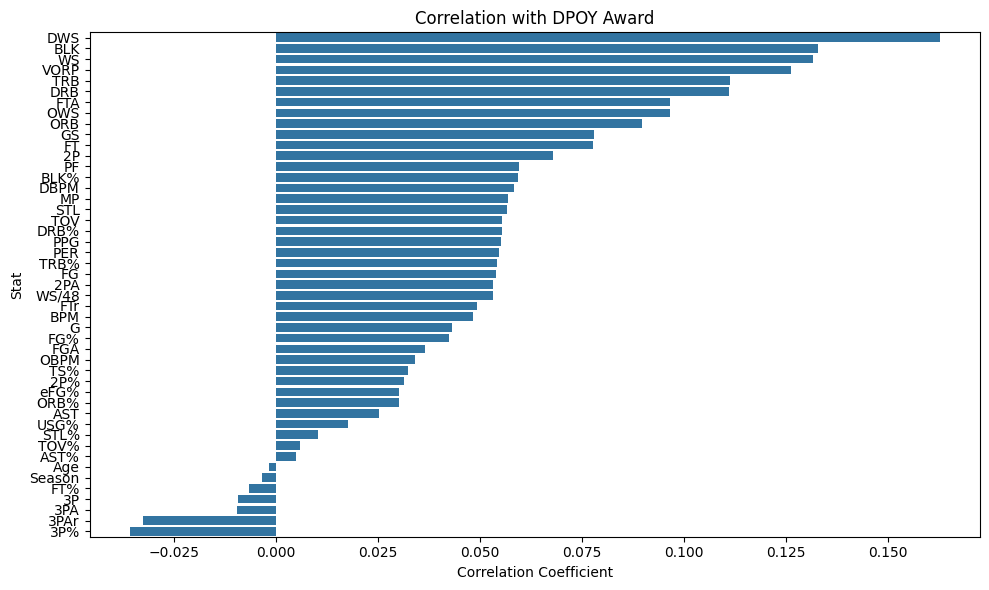

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(x=dpoy_corr.values, y=dpoy_corr.index)
plt.title("Correlation with DPOY Award")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Stat")
plt.tight_layout()
plt.show()

Based on the results here, we're going to take everything with a correlation coefficient >.050

In [10]:
important_stats = dpoy_corr[dpoy_corr > 0.050].index

In [11]:
dpoy_eda = players_df[list(important_stats) + ["is_DPOY"]]

In [12]:
print(dpoy_eda.head())
print(f"{dpoy_eda.shape[1]-1} stats selected with correlation > 0.080")

   DWS  BLK    WS  VORP  TRB  DRB   FTA   OWS  ORB    GS  ...  STL  TOV  DRB%  \
0  5.0  1.0  16.1   7.5  7.6  6.3  10.2  11.1  1.3  82.0  ...  1.4  3.3  17.9   
1  5.2  1.0  18.5  10.3  7.3  6.4  10.2  13.3  0.9  76.0  ...  1.6  3.4  18.5   
2  2.4  0.4   7.9   2.9  6.6  4.4   8.9   5.6  2.2  69.0  ...  1.3  3.0  13.1   
3  4.0  0.3   9.4   4.4  5.4  4.3   7.4   5.4  1.1  73.0  ...  1.5  3.2  12.2   
4  4.6  1.1  13.0   7.9  4.8  3.5   9.1   8.5  1.4  77.0  ...  1.8  3.3  11.1   

    PPG   PER  TRB%    FG   2PA  WS/48  is_DPOY  
0  30.1  26.2  11.0   9.7  16.1  0.238        0  
1  29.7  31.1  11.1  10.1  15.0  0.299        0  
2  28.2  22.2   9.9  10.0  19.1  0.145        0  
3  27.0  21.9   7.7   9.8  17.4  0.160        0  
4  26.6  28.0   7.8   9.3  16.5  0.224        0  

[5 rows x 26 columns]
25 stats selected with correlation > 0.080


Now that we know the correlation between individual stats and the DPOY award, we're going to check for correlation between individual stats and reduce redundancies

In [13]:
# Select numeric feature columns excluding the target (DPOY)
features_only = dpoy_eda.drop(columns=["is_DPOY"])

In [14]:
# Compute the correlation matrix with absolute values
corr = features_only.corr().abs()

In [15]:
# Convert correlation to disatance (1 - correlation)
distance_matrix = 1 - corr

In [16]:
# Use hierarchical clustering (linkage) on the distance matrix
linkage_matrix = linkage(distance_matrix, method="ward")

C:\Users\bartl\AppData\Local\Temp\ipykernel_60536\187123466.py:2: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(distance_matrix, method="ward")


Plotting and using a dendrogram to determine correlation between columns. Features are joined closer to the left are more correlated

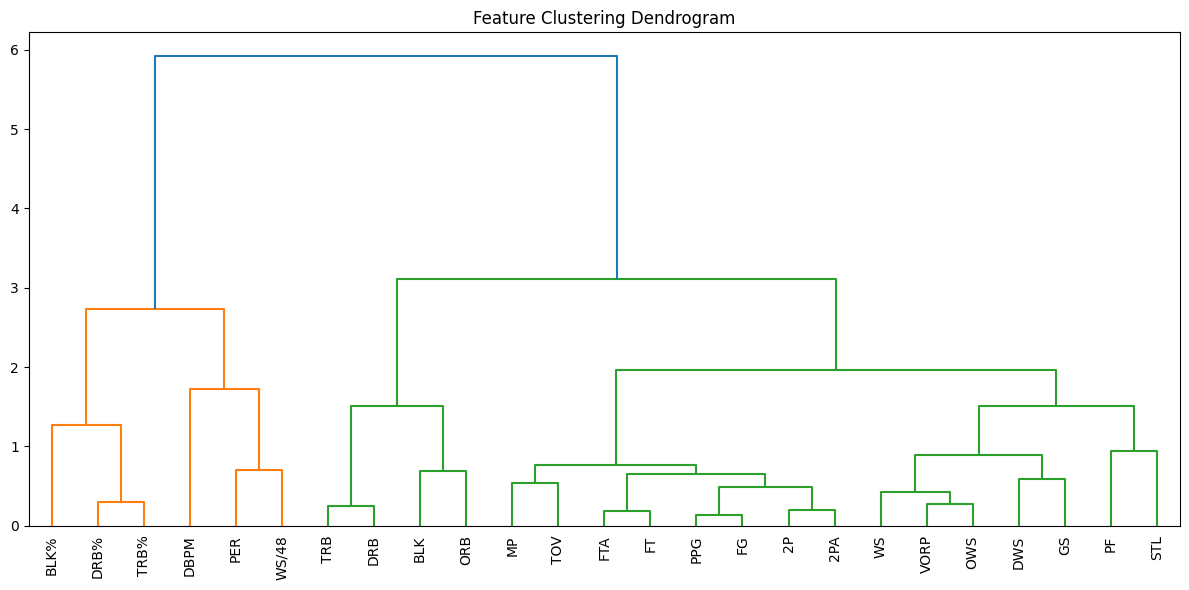

In [17]:
# Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=corr.columns, leaf_rotation=90)
plt.title("Feature Clustering Dendrogram")
plt.tight_layout()
plt.show()

In [18]:
columns_to_drop = ["BLK%", "DRB%", "TRB%", "DBPM", "PER", "WS/48"]
dpoy_eda.drop(columns=columns_to_drop, inplace=True)

C:\Users\bartl\AppData\Local\Temp\ipykernel_60536\3352799617.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dpoy_eda.drop(columns=columns_to_drop, inplace=True)


In [19]:
dpoy_eda.head(5)

,DWS,BLK,WS,VORP,TRB,DRB,FTA,OWS,ORB,GS,FT,2P,PF,MP,STL,TOV,PPG,FG,2PA,is_DPOY
0,5.0,1.0,16.1,7.5,7.6,6.3,10.2,11.1,1.3,82.0,9.2,8.1,2.1,39.5,1.4,3.3,30.1,9.7,16.1,0
1,5.2,1.0,18.5,10.3,7.3,6.4,10.2,13.3,0.9,76.0,7.8,8.4,1.6,39.0,1.6,3.4,29.7,10.1,15.0,0
2,2.4,0.4,7.9,2.9,6.6,4.4,8.9,5.6,2.2,69.0,7.4,9.1,3.3,38.2,1.3,3.0,28.2,10.0,19.1,0
3,4.0,0.3,9.4,4.4,5.4,4.3,7.4,5.4,1.1,73.0,6.0,8.5,2.6,38.8,1.5,3.2,27.0,9.8,17.4,0
4,4.6,1.1,13.0,7.9,4.8,3.5,9.1,8.5,1.4,77.0,6.9,8.4,2.4,36.3,1.8,3.3,26.6,9.3,16.5,0


In [20]:
feature_corr = dpoy_eda.drop(columns=["is_DPOY"]).corr()

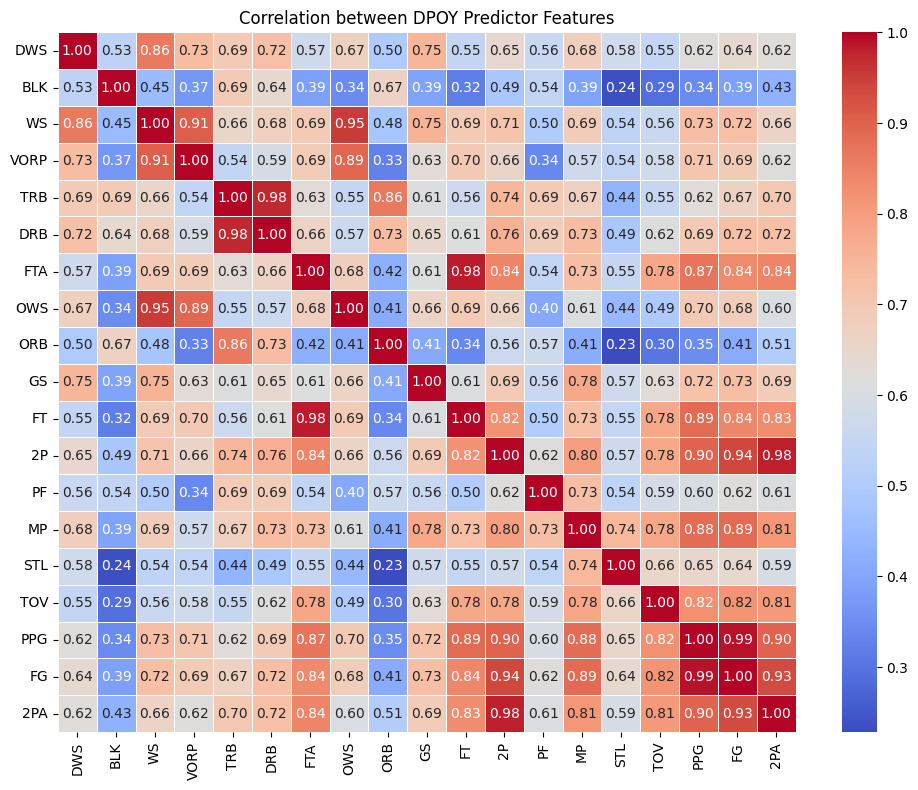

In [21]:
# Visualizing the data using a Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(feature_corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation between DPOY Predictor Features")
plt.tight_layout()
plt.show()

In [22]:
# Creating a correlation matrix of absolute values
corr_matrix = dpoy_eda.drop(columns=["is_DPOY"]).corr().abs()

In [23]:
# Selecting the upper triangle to avoid duplicate pairs
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

In [24]:
# Finding highly correlated feature pairs (pairs over >.85)
high_corr_features = [
    column for column in upper.columns if any(upper[column] > 0.85)
]
print(f"Features to consider droppong due to high correlation: \n{high_corr_features}")

Features to consider droppong due to high correlation: 
['WS', 'VORP', 'DRB', 'OWS', 'ORB', 'FT', 'PPG', 'FG', '2PA']


In [25]:
# New DataFrame with reduced columns
reduced_df = dpoy_eda.drop(columns=high_corr_features)

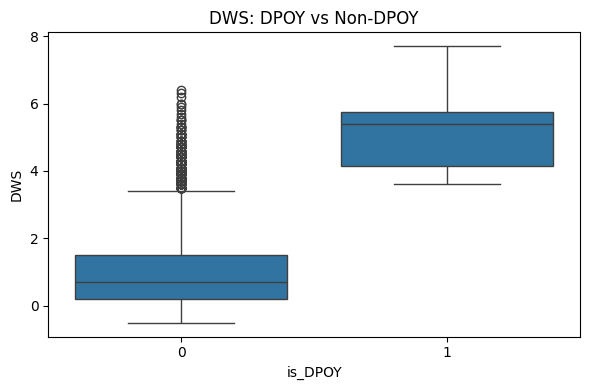

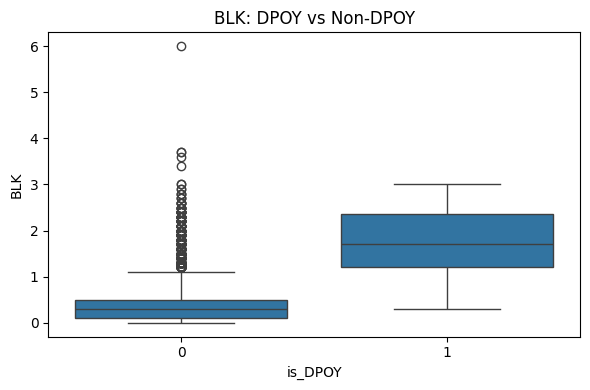

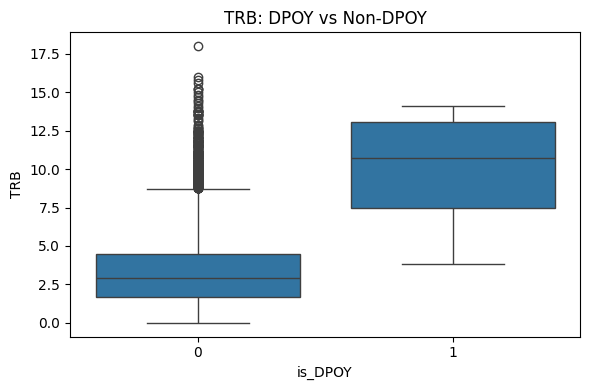

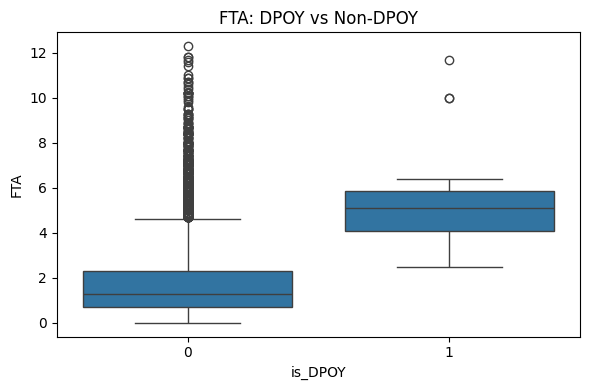

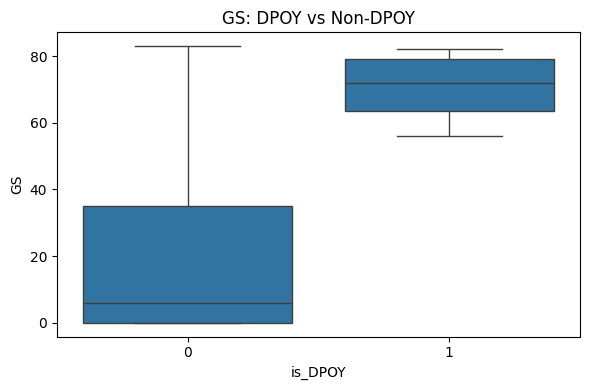

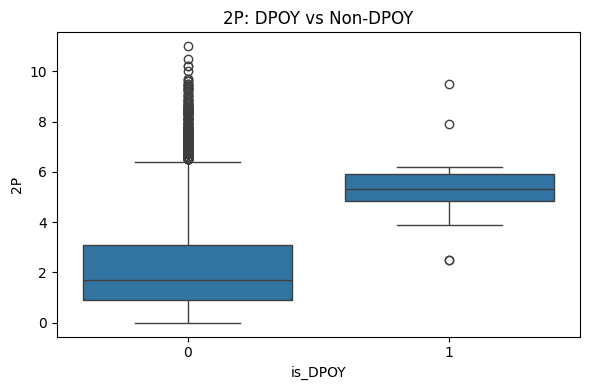

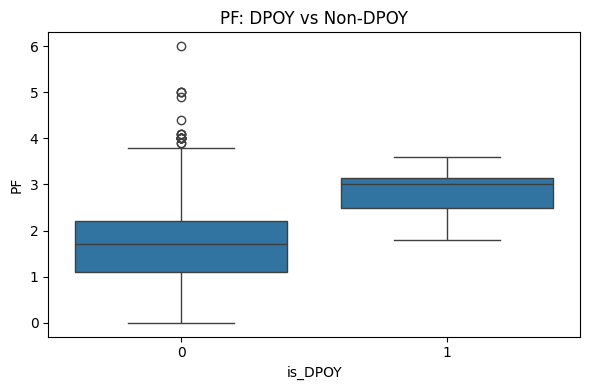

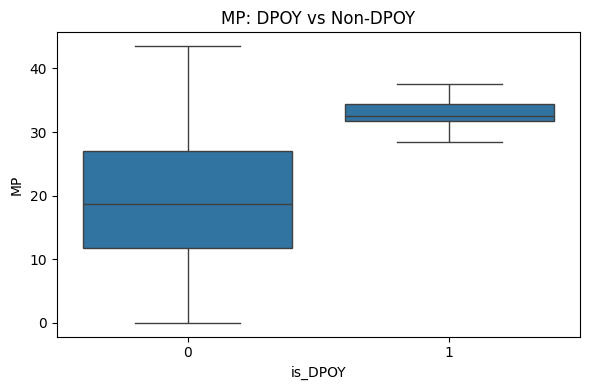

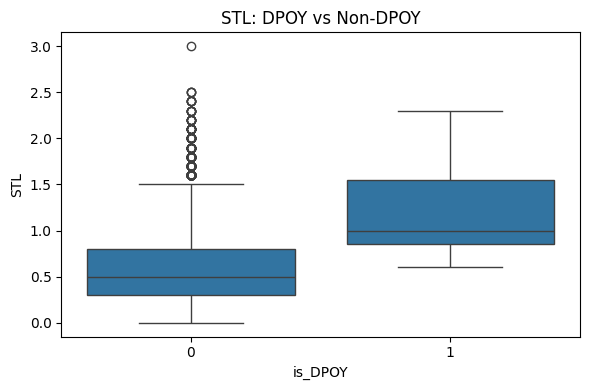

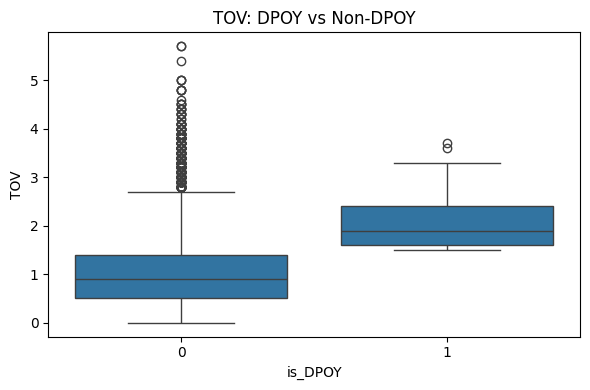

In [26]:
# Visualizing DPOY vs Non-DPOY for Key Features (0 = Non-DPOY, 1 = DPOY)
for col in reduced_df.columns:
    if col != "is_DPOY":
        plt.figure(figsize=(6,4))
        sns.boxplot(x="is_DPOY", y=col, data=reduced_df)
        plt.title(f"{col}: DPOY vs Non-DPOY")
        plt.tight_layout()
        plt.show()

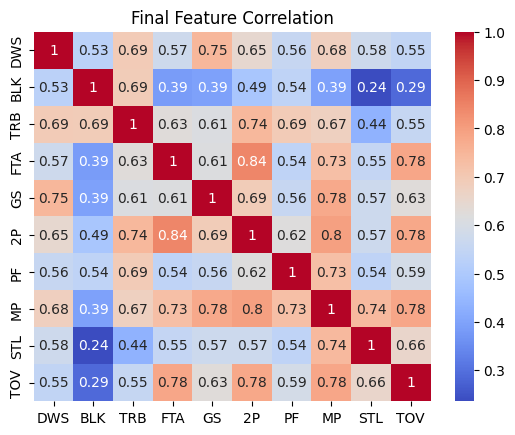

In [27]:
# One last check for redundancy
sns.heatmap(reduced_df.drop(columns="is_DPOY").corr(), annot=True, cmap="coolwarm")
plt.title("Final Feature Correlation")
plt.show()

In [28]:
# Dropping 2P since it is so closely correlated with FTA
last_drop = ["2P"]
dpoy_eda.drop(columns=last_drop, inplace=True)

C:\Users\bartl\AppData\Local\Temp\ipykernel_60536\3551030520.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dpoy_eda.drop(columns=last_drop, inplace=True)


In [29]:
dpoy_eda.head(5)

,DWS,BLK,WS,VORP,TRB,DRB,FTA,OWS,ORB,GS,FT,PF,MP,STL,TOV,PPG,FG,2PA,is_DPOY
0,5.0,1.0,16.1,7.5,7.6,6.3,10.2,11.1,1.3,82.0,9.2,2.1,39.5,1.4,3.3,30.1,9.7,16.1,0
1,5.2,1.0,18.5,10.3,7.3,6.4,10.2,13.3,0.9,76.0,7.8,1.6,39.0,1.6,3.4,29.7,10.1,15.0,0
2,2.4,0.4,7.9,2.9,6.6,4.4,8.9,5.6,2.2,69.0,7.4,3.3,38.2,1.3,3.0,28.2,10.0,19.1,0
3,4.0,0.3,9.4,4.4,5.4,4.3,7.4,5.4,1.1,73.0,6.0,2.6,38.8,1.5,3.2,27.0,9.8,17.4,0
4,4.6,1.1,13.0,7.9,4.8,3.5,9.1,8.5,1.4,77.0,6.9,2.4,36.3,1.8,3.3,26.6,9.3,16.5,0


In [30]:
reduced_df.to_csv(f"{PROCESSED_PATH}/dpoy_eda_cleaned.csv")
print(f"dpoy_eda_cleaned saved to {PROCESSED_PATH}")

dpoy_eda_cleaned saved to ../../data/processed
